<h2>Importing Libraries</h2>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

<h2>Loading the Dataset</h2>

In [5]:
# Creating Database Connection
conn = sqlite3.connect('inventory.db')

# Fetching vendor summary data
df = pd.read_sql_query("SELECT*From vendor_sales_summary",conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesPrice,TotalSalesDollars,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,3960.0,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,74968.0,1212232.56,26863.0,58564.38,590845.37,49358.62,257032.07,-621387.19,-105.169173,0.358326,0.487403
1,1128.0,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,39099.0,1027130.73,12945.0,86771.89,465890.55,23784.45,68601.68,-561240.18,-120.466101,0.331083,0.453584
2,4425.0,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,38153.0,884768.07,12357.0,69520.57,366697.43,22704.08,144929.24,-518070.64,-141.280139,0.323880,0.414456
3,17035.0,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,45340.0,827001.60,15092.0,63821.05,385671.08,27729.28,123780.22,-441330.52,-114.431842,0.332863,0.466349
4,3960.0,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,37118.0,812513.02,15582.0,70172.72,468784.18,28630.00,257032.07,-343728.84,-73.323473,0.419796,0.576956


In [72]:
df = pd.read_sql_query("SELECT*From vendor_sales_summary",conn).to_csv('vendor_sales_summary.csv', index=False)
print('Saved: vendor_sales_summary.csv')

Saved: vendor_sales_summary.csv


<h2>Exploratary Data Analysis</h2>

In [6]:
# Summary Statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,7728.0,1.013898e+04,17721.199433,2.00,3664.000000,7153.000000,9552.000000,1.733570e+05
Brand,7728.0,1.746963e+04,13059.166903,58.00,5229.500000,17040.500000,24788.750000,9.060900e+04
PurchasePrice,7728.0,1.928716e+01,91.781483,0.38,6.750000,10.125000,17.515000,5.681810e+03
ActualPrice,7728.0,2.844546e+01,123.751605,0.49,9.990000,14.990000,25.990000,7.499990e+03
Volume,7728.0,8.594236e+02,594.204627,50.00,750.000000,750.000000,750.000000,1.800000e+04
TotalPurchaseQuantity,7728.0,1.253125e+03,3900.087588,1.00,24.000000,193.000000,935.250000,1.083110e+05
TotalPurchaseDollars,7728.0,1.152182e+04,38861.158547,0.71,318.000000,2316.590000,9660.360000,1.212233e+06
TotalSalesQuantity,7728.0,4.162747e+02,1345.223432,0.00,10.000000,61.000000,303.000000,3.807800e+04
TotalSalesPrice,7728.0,2.715036e+03,5900.885424,0.00,74.950000,629.685000,2747.085000,8.677189e+04
TotalSalesDollars,7728.0,5.571486e+03,18744.852080,0.00,175.582500,1133.410000,4655.345000,5.908454e+05


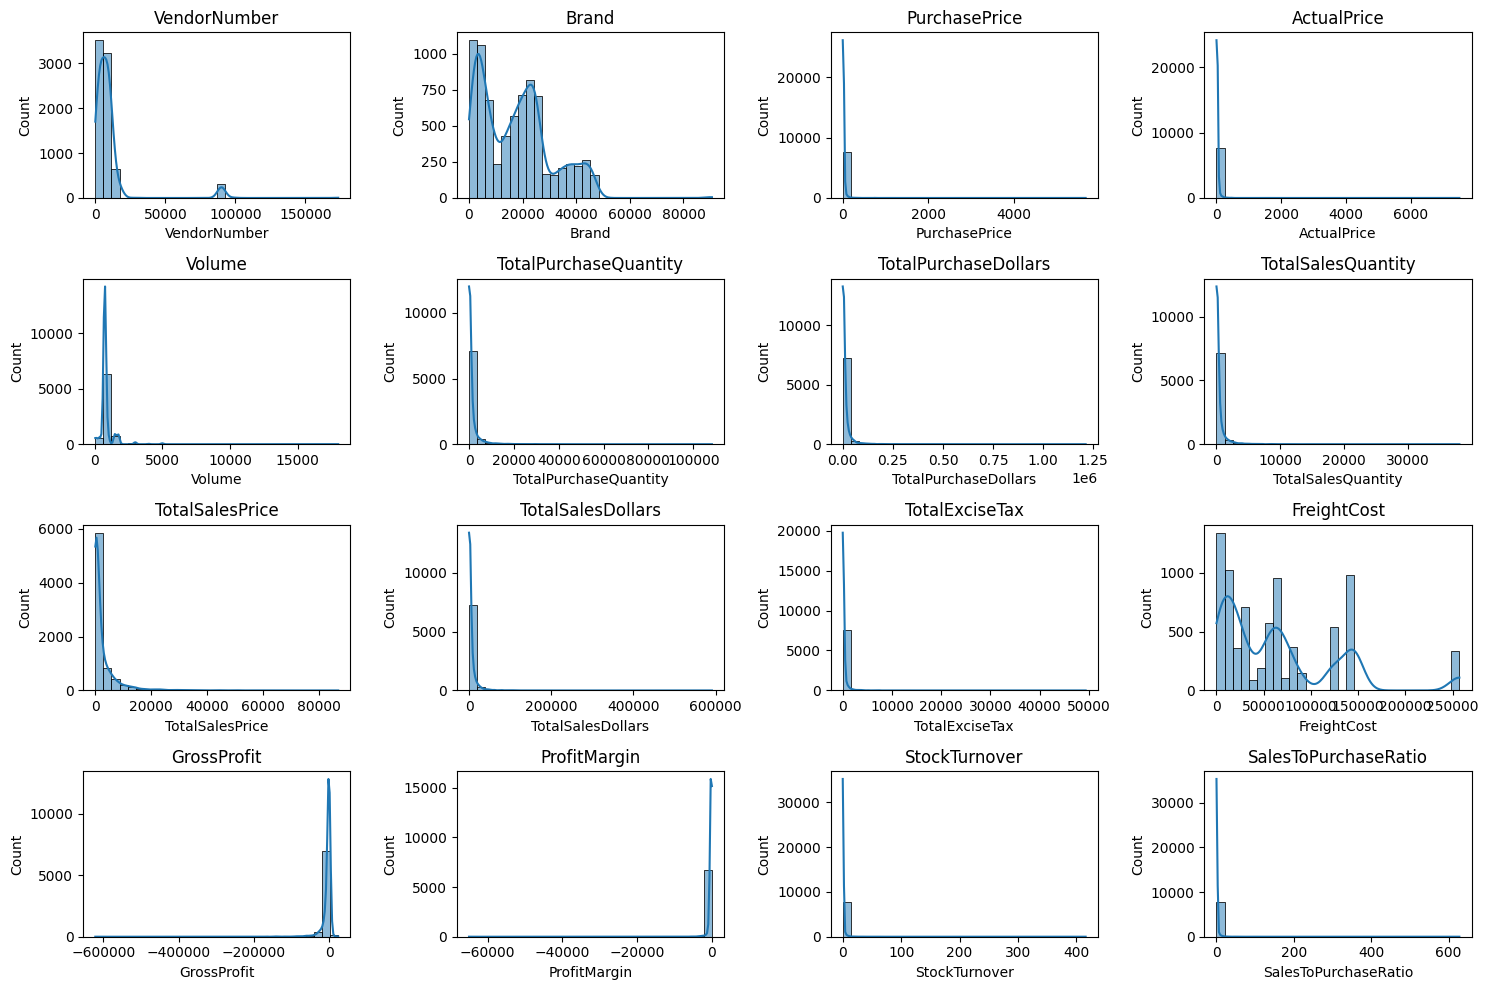

In [7]:
# Distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize = (15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1) #Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

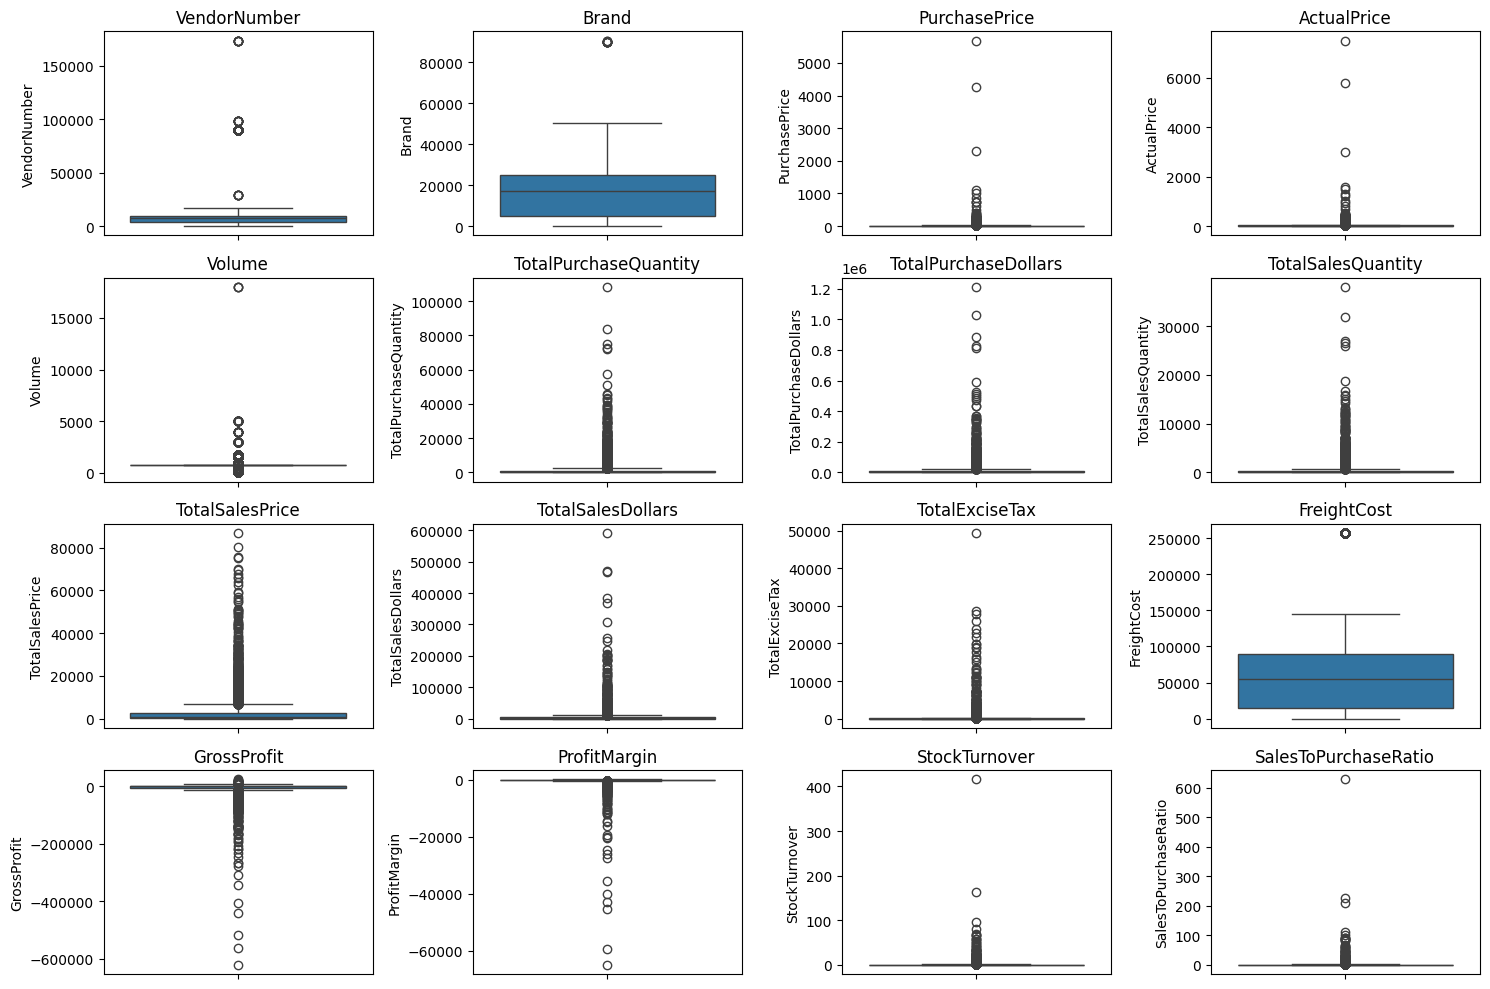

In [8]:
# Outlier Detection with Boxplots
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [9]:
# let's filter the data by removing inconsistencies
df = pd.read_sql_query(
    """SELECT*
    FROM vendor_sales_summary
    WHERE GrossProfit > 0
    AND ProfitMargin > 0
    AND TotalSalesQuantity > 0
    """,conn
)
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesPrice,TotalSalesDollars,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,4425.0,MARTIGNETTI COMPANIES,11219,Josh Cellars Cab Svgn Sonoma,8.44,12.99,750.0,14550.0,122802.00,8305.0,27108.15,125455.95,931.45,144929.24,2653.95,2.115444,0.570790,1.021612
1,4425.0,MARTIGNETTI COMPANIES,6579,J Lohr Riverstone Chard,5.80,8.99,750.0,14513.0,84175.40,8548.0,17684.50,95559.52,959.44,144929.24,11384.12,11.913120,0.588989,1.135243
2,1392.0,CONSTELLATION BRANDS INC,6650,Simi Chard,7.38,14.99,750.0,9631.0,71076.78,8537.0,14443.40,94861.63,958.55,79528.99,23784.85,25.073204,0.886408,1.334636
3,4425.0,MARTIGNETTI COMPANIES,6983,J Lohr Seven Oaks Cab Svgn,8.27,11.99,750.0,5458.0,45137.66,3987.0,17920.08,64610.13,446.51,144929.24,19472.47,30.138416,0.730487,1.431402
4,4425.0,MARTIGNETTI COMPANIES,39335,Phillips Seven Deadly Znfdl,8.75,14.99,750.0,5114.0,44747.50,3846.0,18887.40,57651.54,430.34,144929.24,12904.04,22.382819,0.752053,1.288375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1477,3960.0,DIAGEO NORTH AMERICA INC,8729,Smirnoff Light Strawberry,0.74,0.99,50.0,4.0,2.96,6.0,2.97,5.94,0.31,257032.07,2.98,50.168350,1.500000,2.006757
1478,9815.0,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2.0,2.64,3.0,5.97,5.97,0.33,27100.41,3.33,55.778894,1.500000,2.261364
1479,9815.0,WINE GROUP INC,22407,Three Wishes Chard,2.25,3.29,750.0,1.0,2.25,1.0,3.29,3.29,0.11,27100.41,1.04,31.610942,1.000000,1.462222
1480,9165.0,ULTRA BEVERAGE COMPANY LLP,9191,Mojoshot Blue Lagoon RTD,0.73,0.99,50.0,3.0,2.19,126.0,59.40,124.74,6.49,68054.70,122.55,98.244348,42.000000,56.958904


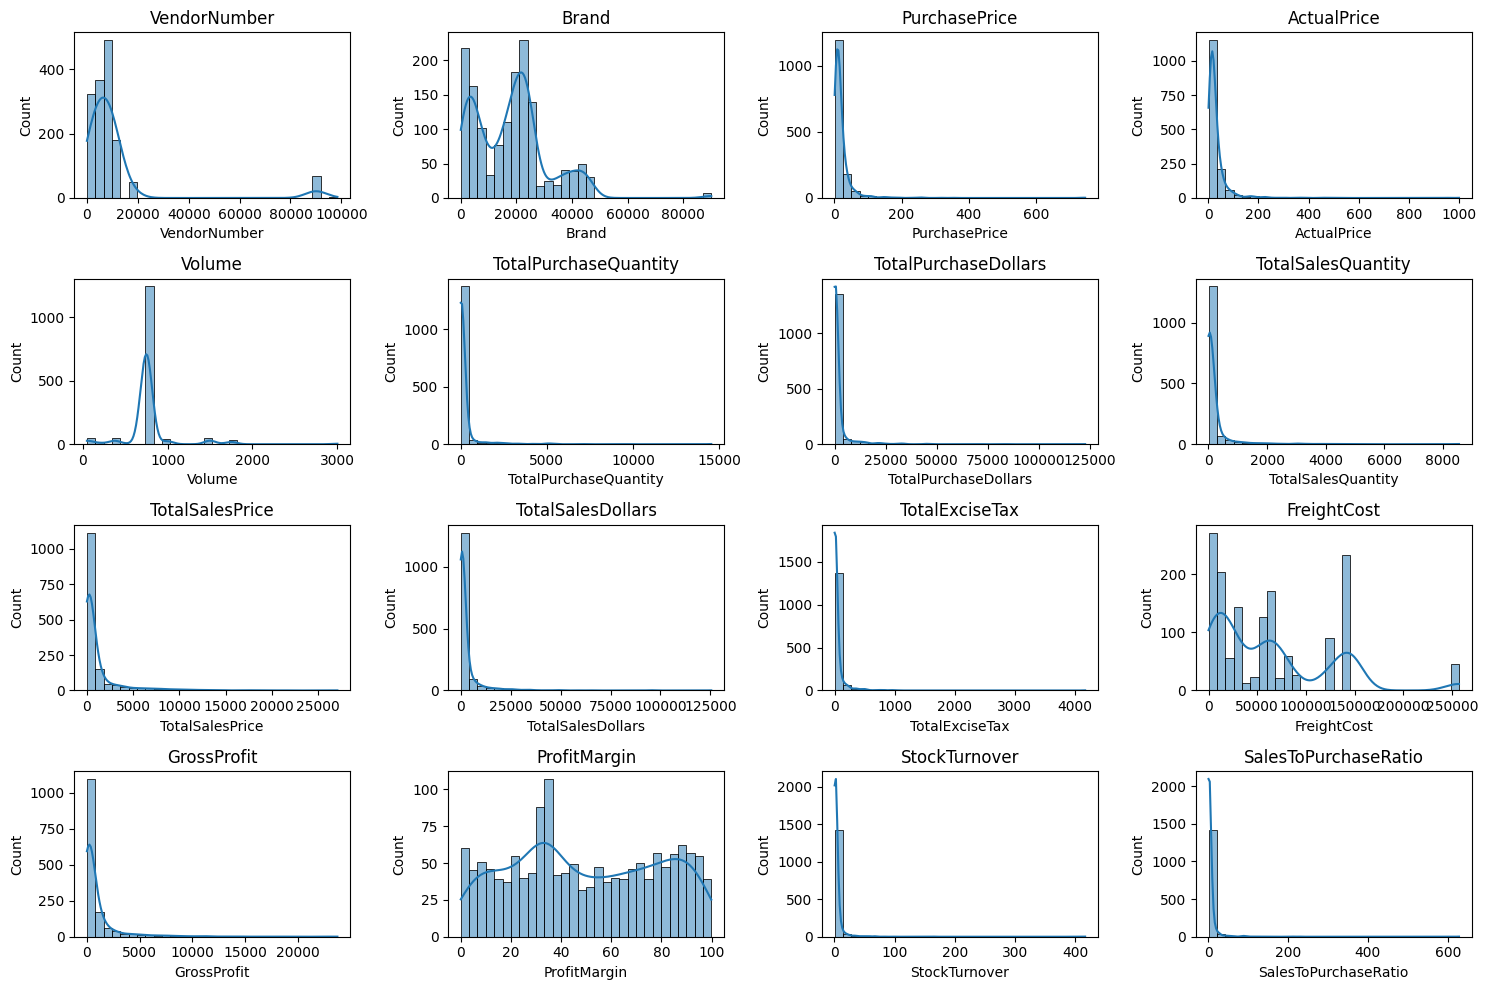

In [10]:
# Distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize = (15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1) #Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

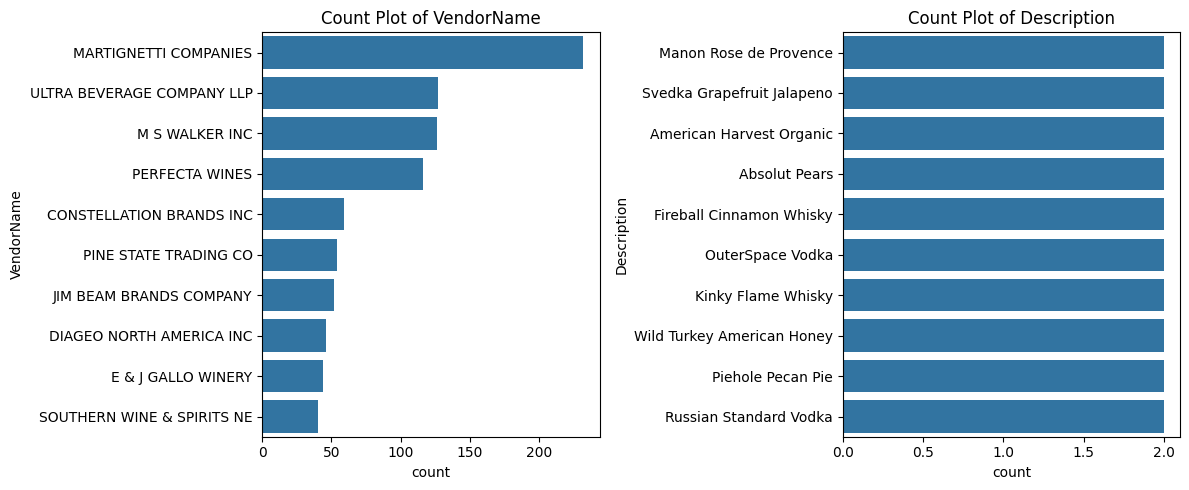

In [11]:
# Count Plots for Categorical Columns
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize = (12,5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i+1) 
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10]) #Top 10 categories
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

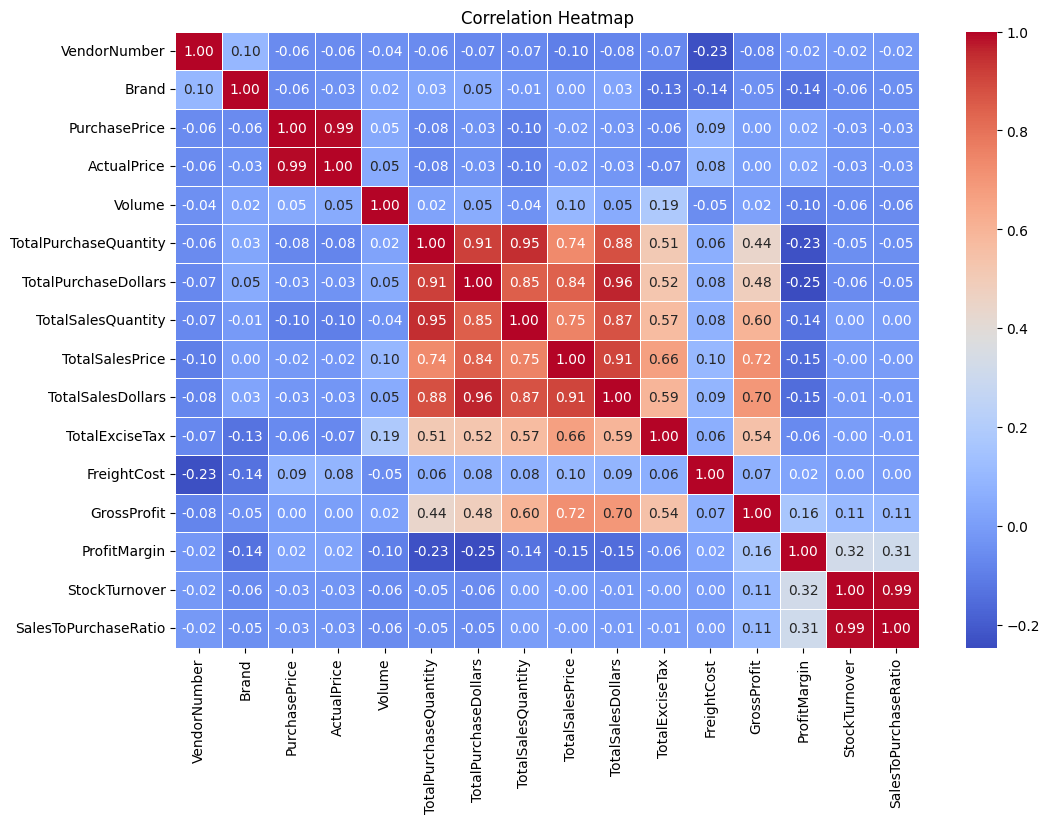

In [12]:
# Correlation Heatmap
plt.figure(figsize = (12, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

<h1>Data Analysis</h1>

Idetify Brands that needs Promotional or Pricing Adjustments which exhibit lower sales performance but higher profit margins.

In [13]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars':'sum',
    'ProfitMargin':'mean'
}).reset_index()

In [14]:
Low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
High_sales_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [15]:
Low_sales_threshold

142.86

In [16]:
High_sales_threshold

85.58462529340372

In [17]:
# Filter brands with low sales but high profit margins

target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= Low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= High_sales_threshold) 
]

print('Brands with Low Sales Sales but High Profit Margins')
display(target_brands.sort_values('TotalSalesDollars'))

Brands with Low Sales Sales but High Profit Margins


,Description,TotalSalesDollars,ProfitMargin
1372,Tracia Syrah,44.94,88.495772
246,Canaletto Pnt Grigio Venezie,47.95,89.113660
98,Bacardi Oakheart Spiced Trav,59.94,87.554221
620,Glen Ellen Pnt Grigio RSV,62.91,92.783341
1122,Rio Madre 2014 Rose Rioja,69.93,90.476190
1071,Promesses de France CdRhone,71.91,92.337644
930,Montsarra Brut Cava,74.95,86.844563
179,Bols Yogurt Liqueur,77.94,87.464716
1342,Three Olives Grape Vodka,80.19,99.114603
1244,St Germain Liqueur,89.94,87.658439


In [18]:
brand_performance = brand_performance[brand_performance['TotalSalesDollars']<10000] #for Better visualization

In [51]:
brand_performance.to_csv('brand_performance.csv', index=False)
print('Saved: brand_performance.csv')

Saved: brand_performance.csv


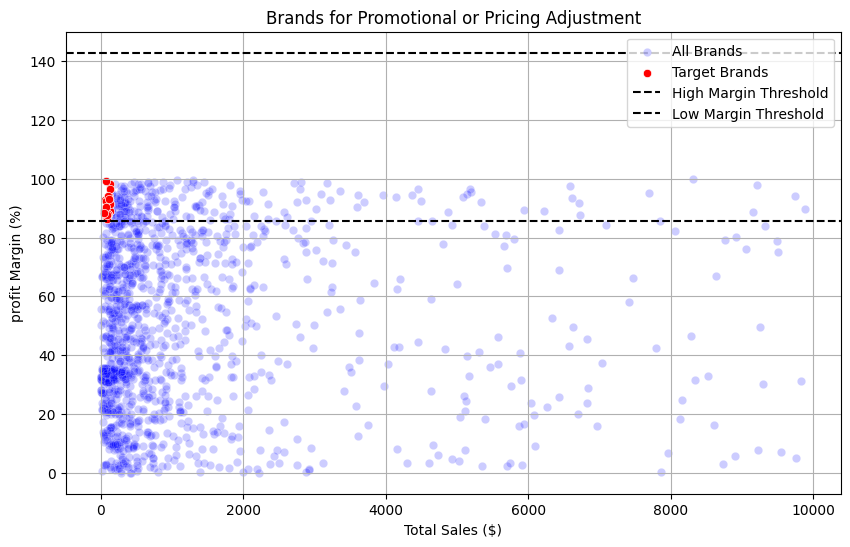

In [22]:
plt.figure(figsize =(10,6))
sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='ProfitMargin', color="Blue", label="All Brands", alpha = 0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin', color="Red", label="Target Brands")

plt.axhline(High_sales_threshold, linestyle='--', color='black', label="High Margin Threshold")
plt.axhline(Low_sales_threshold, linestyle='--', color='black', label="Low Margin Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustment")
plt.legend()
plt.grid(True)
plt.show()

<h3>Which vendor and Brands demonstrate the highest sales performance?</h3>

In [23]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return str(value)

In [24]:
# Top Vendors & Brands by sales Performance
top_vendors = df.groupby('VendorName')["TotalSalesDollars"].sum().nlargest(10)
top_brands = df.groupby('Description')["TotalSalesDollars"].sum().nlargest(10)
top_vendors

VendorName
MARTIGNETTI COMPANIES          1060838.14
CONSTELLATION BRANDS INC        374348.83
ULTRA BEVERAGE COMPANY LLP      264184.30
M S WALKER INC                  236465.40
PERFECTA WINES                  188787.07
DIAGEO CHATEAU ESTATE WINES     167324.83
E & J GALLO WINERY              129011.93
BACARDI USA INC                 124471.24
DIAGEO NORTH AMERICA INC        121606.34
STE MICHELLE WINE ESTATES       113726.40
Name: TotalSalesDollars, dtype: float64

In [25]:
top_brands

Description
Josh Cellars Cab Svgn Sonoma    125455.95
J Lohr Riverstone Chard          95559.52
Simi Chard                       94861.63
J Lohr Seven Oaks Cab Svgn       64610.13
Phillips Seven Deadly Znfdl      57651.54
Sterling Vintners Cab Svgn C     49742.76
Sebastiani Znfdl Sonoma Cnty     48381.57
Simi Cab Svgn                    48290.36
Sterling Vintners Cltn Chard     44417.47
Bacardi Gold Rum Traveler        40873.28
Name: TotalSalesDollars, dtype: float64

In [26]:
top_brands.apply(lambda x : format_dollars(x))

Description
Josh Cellars Cab Svgn Sonoma    125.46K
J Lohr Riverstone Chard          95.56K
Simi Chard                       94.86K
J Lohr Seven Oaks Cab Svgn       64.61K
Phillips Seven Deadly Znfdl      57.65K
Sterling Vintners Cab Svgn C     49.74K
Sebastiani Znfdl Sonoma Cnty     48.38K
Simi Cab Svgn                    48.29K
Sterling Vintners Cltn Chard     44.42K
Bacardi Gold Rum Traveler        40.87K
Name: TotalSalesDollars, dtype: object

In [27]:
top_vendors.apply(lambda x : format_dollars(x))

VendorName
MARTIGNETTI COMPANIES            1.06M
CONSTELLATION BRANDS INC       374.35K
ULTRA BEVERAGE COMPANY LLP     264.18K
M S WALKER INC                 236.47K
PERFECTA WINES                 188.79K
DIAGEO CHATEAU ESTATE WINES    167.32K
E & J GALLO WINERY             129.01K
BACARDI USA INC                124.47K
DIAGEO NORTH AMERICA INC       121.61K
STE MICHELLE WINE ESTATES      113.73K
Name: TotalSalesDollars, dtype: object

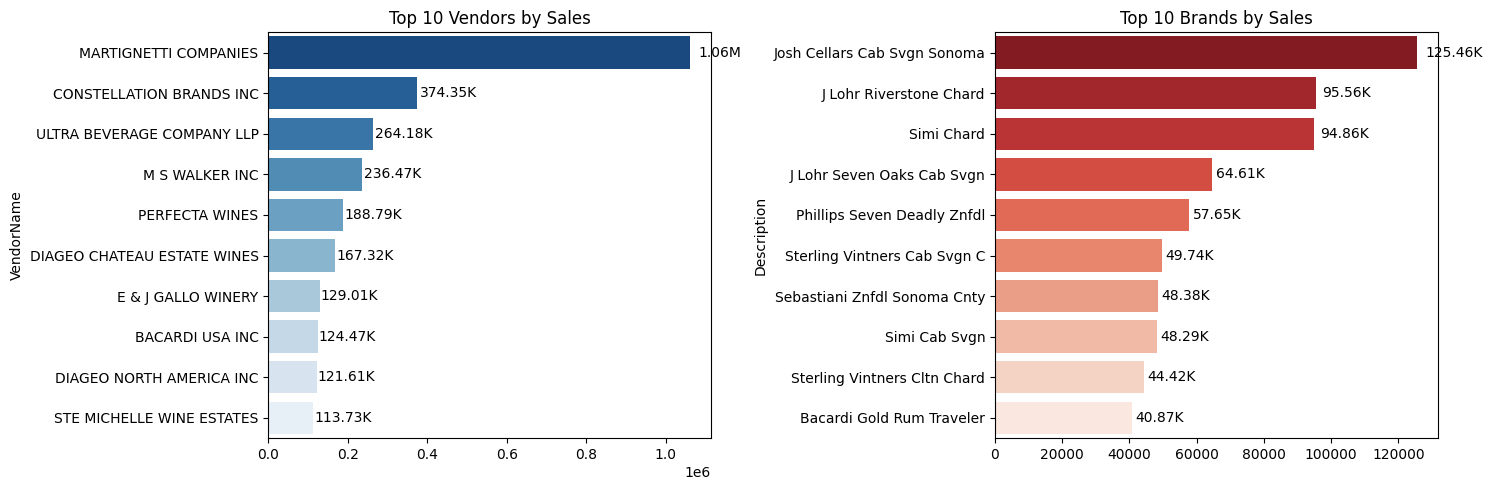

In [28]:
plt.figure(figsize=(15,5))
# Plot for Top Vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars ( bar.get_width()),
        ha='left', va='center' , fontsize=10, color='Black')
    
# Plot for Top Brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(y=top_brands.index.astype(str), x= top_brands.values, palette="Reds_r")
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()) ,
        ha='left', va='center' , fontsize=10, color='black' )

plt.tight_layout()
plt.show()

<h3>Which Vendors contribute the most to total purchase dollars?</h3>

In [29]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum'
}).reset_index()

In [30]:
vendor_performance['PurchaseContribution%'] = vendor_performance['TotalPurchaseDollars']/vendor_performance['TotalPurchaseDollars'].sum()*100
vendor_performance = round(vendor_performance.sort_values('PurchaseContribution%' , ascending= False),2)

In [31]:
# Display Top 10 Vendors
top_vendors = vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
37,MARTIGNETTI COMPANIES,763.83K,297.01K,1.06M,30.67
9,CONSTELLATION BRANDS INC,280.16K,94.19K,374.35K,11.25
71,ULTRA BEVERAGE COMPANY LLP,129.20K,134.99K,264.18K,5.19
34,M S WALKER INC,124.11K,112.35K,236.47K,4.98
46,PERFECTA WINES,111.51K,77.28K,188.79K,4.48
18,E & J GALLO WINERY,103.62K,25.39K,129.01K,4.16
13,DIAGEO CHATEAU ESTATE WINES,94.68K,72.64K,167.32K,3.80
63,STE MICHELLE WINE ESTATES,92.16K,21.57K,113.73K,3.70
70,TRINCHERO FAMILY ESTATES,75.75K,15.20K,90.95K,3.04
14,DIAGEO NORTH AMERICA INC,74.07K,47.54K,121.61K,2.97


In [32]:
top_vendors['Cumulative_Contribution%'] = top_vendors['PurchaseContribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cumulative_Contribution%
37,MARTIGNETTI COMPANIES,763.83K,297.01K,1.06M,30.67,30.67
9,CONSTELLATION BRANDS INC,280.16K,94.19K,374.35K,11.25,41.92
71,ULTRA BEVERAGE COMPANY LLP,129.20K,134.99K,264.18K,5.19,47.11
34,M S WALKER INC,124.11K,112.35K,236.47K,4.98,52.09
46,PERFECTA WINES,111.51K,77.28K,188.79K,4.48,56.57
18,E & J GALLO WINERY,103.62K,25.39K,129.01K,4.16,60.73
13,DIAGEO CHATEAU ESTATE WINES,94.68K,72.64K,167.32K,3.80,64.53
63,STE MICHELLE WINE ESTATES,92.16K,21.57K,113.73K,3.70,68.23
70,TRINCHERO FAMILY ESTATES,75.75K,15.20K,90.95K,3.04,71.27
14,DIAGEO NORTH AMERICA INC,74.07K,47.54K,121.61K,2.97,74.24


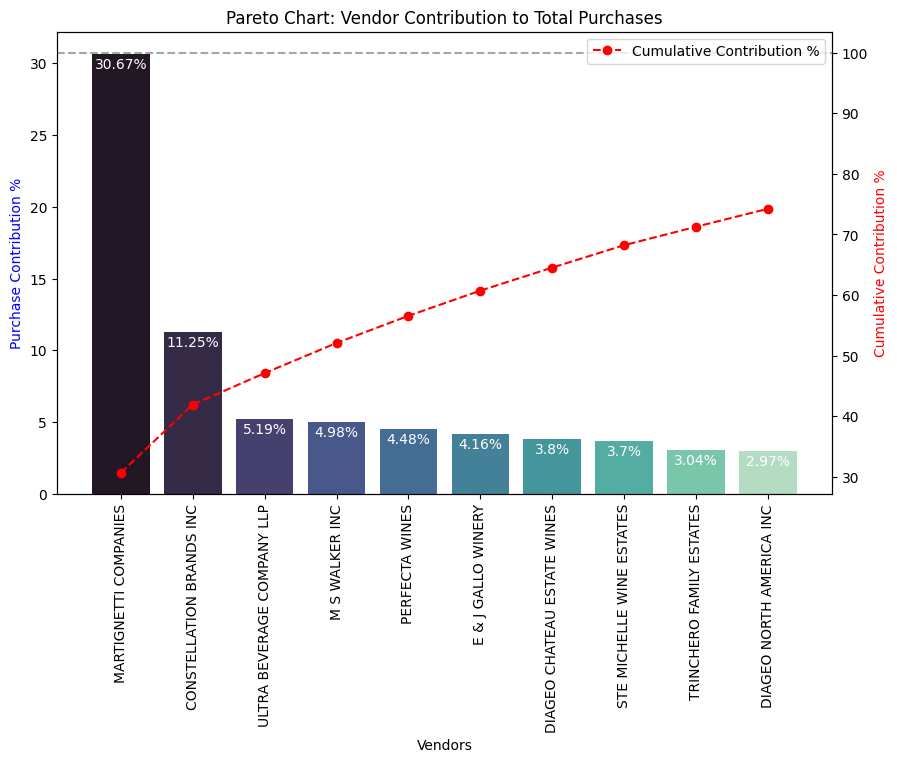

In [33]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Purchase Contribution%
sns.barplot(x=top_vendors['VendorName'], y=top_vendors['PurchaseContribution%'], palette="mako", ax=ax1)

for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i, value - 1, str(value)+'%', ha='center', fontsize=10, color='white')
    
# Line Plot for Cumulative Contribution%
ax2 = ax1.twinx()
ax2.plot(top_vendors['VendorName'], top_vendors['Cumulative_Contribution%'], color='red', marker='o', linestyle='dashed', label= 'Cumulative Contribution %')

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel( 'Cumulative Contribution %', color='red')
ax1.set_xlabel( 'Vendors' )
ax1.set_title( 'Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend( loc='upper right')

plt.show()

<h3>How much of total procurement is dependent on the top vendors?</h3>

In [34]:
print(f"Total Purchase Contribution of top 10 vendors is {round(top_vendors['PurchaseContribution%'].sum(),2)}")

Total Purchase Contribution of top 10 vendors is 74.24


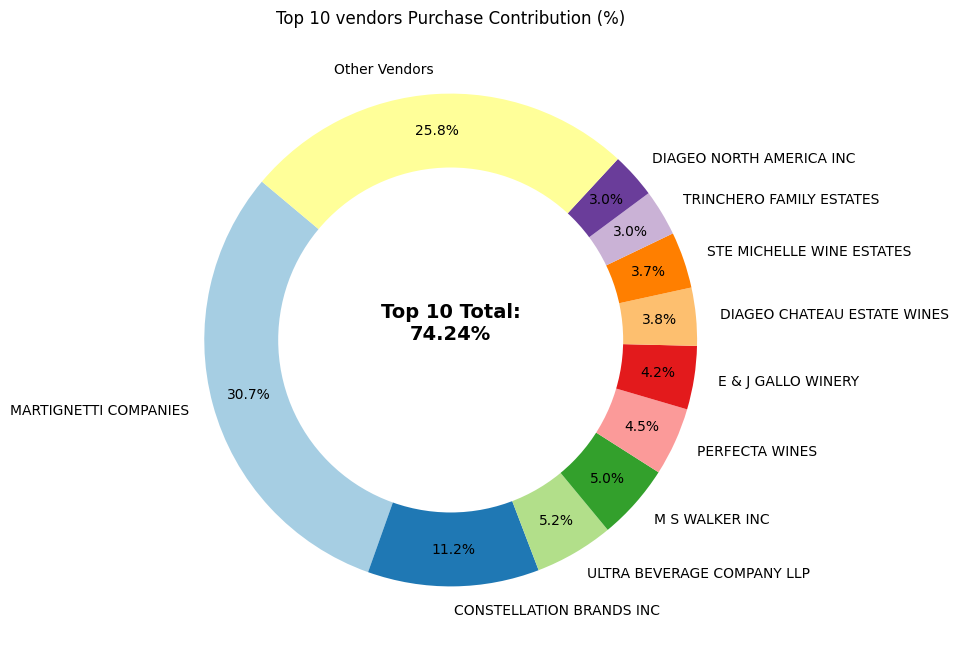

In [35]:
vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['PurchaseContribution%'].values)
total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

#Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

#Donut Chart
fig, ax = plt.subplots(figsize=(8,8))
wedges, texts, autotexts = ax.pie(purchase_contributions, labels=vendors, autopct='%1.1f%%',
                                  startangle=140, pctdistance=0.85, colors=plt.cm.Paired.colors)

#Draw a white circle in the center to create a "donut" effect
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

#Add Total Contribution annotation in the center
plt.text(0,0, f"Top 10 Total:\n{total_contribution:.2f}%", fontsize=14, fontweight='bold', ha='center')

plt.title("Top 10 vendors Purchase Contribution (%)")
plt.show()

In [58]:
purchase_contributions_df = pd.DataFrame(purchase_contributions)
purchase_contributions_df.to_csv('purchase_contributions.csv', index=False)

print('Saved: purchase_contributions.csv')

Saved: purchase_contributions.csv


<h3>Does purchasing in bulk reduce the unit price, and what is the optimal purchase volume for cost savings?</h3>

In [36]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']

In [37]:
df['OrderSize'] = pd.qcut(df['TotalPurchaseQuantity'], q=3, labels=["small","Medium","Large"])

In [38]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
small,33.329316
Medium,16.224178
Large,10.791565


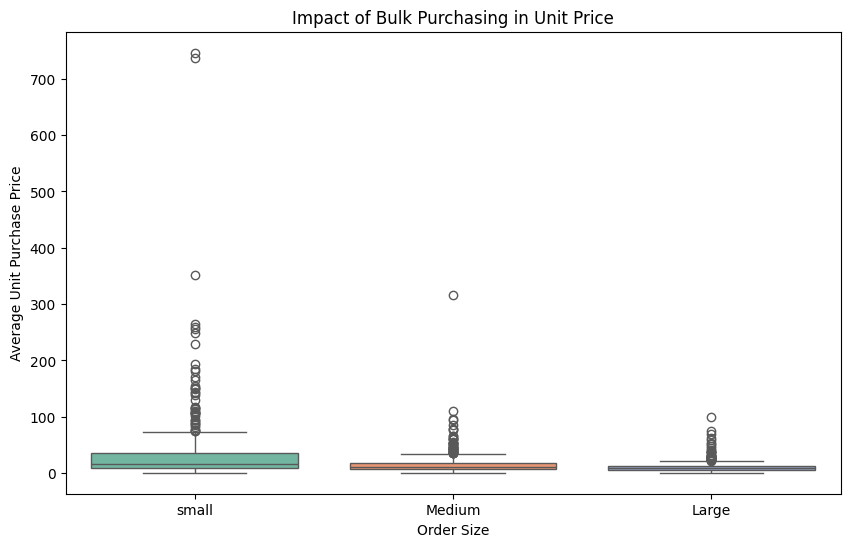

In [39]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='OrderSize' , y="UnitPurchasePrice", palette="Set2")
plt.title("Impact of Bulk Purchasing in Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

• Vendors buying in bulk (Large Order Size) get the lowest unit prife ($10.78 per unit), meaning higher margins if they can manage inventory efficiently.

• This suggests that bulk pricing strategies successfully encourage vendors to purchase in larger volumes, leading to higher overall sales despite lower per-unit revenue.

<h3>Which Vendor have low inventory turnover, indicating excess stock and slow-moving products?</h3>

In [40]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover', ascending=True).head(10)

,StockTurnover
VendorName,
SEA BREEZE CELLARS LLC,0.555276
SURVILLE ENTERPRISES CORP,0.571849
Circa Wines,0.588889
HEAVEN HILL DISTILLERIES,0.618138
CRUSH WINES,0.648649
R.P.IMPORTS INC,0.666667
LUXCO INC,0.666667
E & J GALLO WINERY,0.678136
TREASURY WINE ESTATES,0.702745


In [69]:
low_turnover_vendors = (
    df[df['StockTurnover'] < 1]
    .groupby('VendorName', as_index=False)['StockTurnover']
    .mean()
    .sort_values('StockTurnover', ascending=True)
    .head(20)
)

In [70]:
low_turnover_vendors.to_csv('low_turnover_vendors.csv', index=False)

<h3>How much capital is locked in unsold inventory per vendor, and which vendors contribute the most to it?</h3>

In [41]:
df["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) * df["PurchasePrice"]
print('Total Unsold Capital:', format_dollars(df["UnsoldInventoryValue"].sum()))

Total Unsold Capital: -37013.71000000008


In [42]:
# Aggregate Capital Locked per Vendor
inventory_value_per_vendor = df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

# Sort vendors with Highest locked Capital
inventory_value_per_vendor  = inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending=False)
inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
37,MARTIGNETTI COMPANIES,132.63K
9,CONSTELLATION BRANDS INC,47.72K
18,E & J GALLO WINERY,24.93K
63,STE MICHELLE WINE ESTATES,21.58K
69,TREASURY WINE ESTATES,18.37K
70,TRINCHERO FAMILY ESTATES,17.05K
3,BANFI PRODUCTS CORP,16.94K
23,FREDERICK WILDMAN & SONS,5.18K
79,WINE GROUP INC,3.34K
13,DIAGEO CHATEAU ESTATE WINES,1.31K


<h3>What is the 95% confidence intervals for profit margins of top-performing and low-performing vendors?</h3>

In [43]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

In [44]:
top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

In [45]:
top_vendors

0        2.115444
1       11.913120
2       25.073204
3       30.138416
4       22.382819
          ...    
1222    98.524454
1239    98.394028
1276    98.006249
1329    99.017859
1419    99.840786
Name: ProfitMargin, Length: 371, dtype: float64

In [46]:
low_vendors

765      3.478509
770      8.048532
776      1.035929
777      9.257715
796      9.919312
          ...    
1477    50.168350
1478    55.778894
1479    31.610942
1480    98.244348
1481    99.114603
Name: ProfitMargin, Length: 371, dtype: float64

In [47]:
def confidence_interval(data, confidence = 0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data)-1)
    t_critical = stats.t.ppf((1 + confidence) / 2, df = len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top Vendors 95% CI: (44.00, 50.54, Mean: 47.27)
Low Vendors 95% CI: (42.93, 48.05, Mean: 45.49)


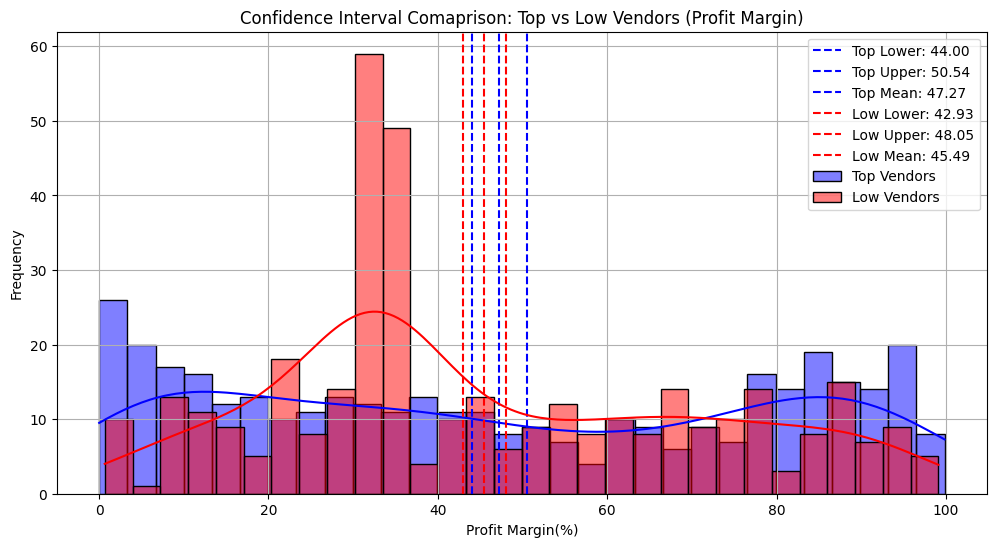

In [48]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}, Mean: {top_mean:.2f})")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}, Mean: {low_mean:.2f})")

plt.figure(figsize=(12,6))

# Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="--", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="--", label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Interval Comaprison: Top vs Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin(%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

       

• The confidence interval for low-performing vendors (40.48% to 42.62%) is significantly higher than that of top-performing vendors (30.74% to 31.61%).

• This suggests that vendors with lower sales tend to maintain higher profit margins, potentially due to premium pricing or lower operational costs.

• For High-Performing Vendors: If they aim to improve profitability, they could explore selective price adjustments, cost optimization, or bundling strategies.

• For Low-Performing Vendors: Despite higher margins, their low sales volume might indicate a need for better marketing, competitive pricing, or improved
distribution strategies.

<h3>Is there a significant difference in profit margins between top-performing and low-performing vendors?</h3>

Hypothesis:

Ho (Null Hypothesis): There is no significant difference in the mean profit margins of top-performing and low-performing vendors.

H1 (Alternative Hypothesis): The mean profit margins of top-performing and low-performing vendors are significantly different.

In [49]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistics: {t_stat:.4f}, P-Value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject H0: There is a significant difference in profit margins between top and low_performing vendors.")
else:
    print("Fail to Reject h0: No significant difference in profit margins")

T-Statistics: 0.8431, P-Value: 0.3995
Fail to Reject h0: No significant difference in profit margins
